In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [14]:
df = pd.read_csv("/Users/droogately/python_decal_fall2025/course_assignments/homework9/solar_system.csv")

In [15]:
print(df.shape)

(20, 11)


In [16]:
num_rows, num_cols = df.shape
print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

Number of rows: 20
Number of columns: 11


In [17]:
print(df.head())

                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  


In [18]:
print(df.tail())

                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring System?      No    No    No   No    No      Yes      Yes   
19   Global Magnetic Field?     Yes    No   Yes   No    No      Yes      Yes   

     Uranus  Neptune    Pluto  
15     -195     -200     -225  
16  Unknown  Unknown  0.00001  
17       28       16        5  
18      Yes      Yes       No  
19      Yes      Yes  Unknown  


In [7]:
print(df.columns.tolist())

['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune', 'Pluto']


In [20]:
print(df['Attribute'])

0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object


In [19]:
orbital_period = df.iloc[5, 1:].astype(float)
perihelion = df.iloc[6, 1:].astype(float)
aphelion = df.iloc[7, 1:].astype(float)

print("Orbital Period:\n", orbital_period)
print("\nPerihelion:\n", perihelion)
print("\nAphelion:\n", aphelion)

Orbital Period:
 Mercury    1407.6
Venus     -5832.5
Earth        23.9
Moon        655.7
Mars         24.6
Jupiter       9.9
Saturn       10.7
Uranus      -17.2
Neptune      16.1
Pluto      -153.3
Name: 5, dtype: float64

Perihelion:
 Mercury    4222.6
Venus      2802.0
Earth        24.0
Moon        708.7
Mars         24.7
Jupiter       9.9
Saturn       10.7
Uranus       17.2
Neptune      16.1
Pluto       153.3
Name: 6, dtype: float64

Aphelion:
 Mercury      57.900
Venus       108.200
Earth       149.600
Moon          0.384
Mars        228.000
Jupiter     778.500
Saturn     1432.000
Uranus     2867.000
Neptune    4515.000
Pluto      5906.400
Name: 7, dtype: float64


In [21]:
semi_major_axis = (perihelion + aphelion) / 2

In [22]:
print(semi_major_axis)

Mercury    2140.250
Venus      1455.100
Earth        86.800
Moon        354.542
Mars        126.350
Jupiter     394.200
Saturn      721.350
Uranus     1442.100
Neptune    2265.550
Pluto      3029.850
dtype: float64


In [23]:
semi_major_axis_row = pd.Series(
    [ "Semi-Major Axis (AU)" ] + semi_major_axis.tolist(),
    index=df.columns
)
df = pd.concat([df, semi_major_axis_row.to_frame().T], ignore_index=True)
print(df.tail())

                  Attribute  Mercury   Venus Earth     Moon    Mars  Jupiter  \
16  Surface Pressure (bars)        0      92     1        0    0.01  Unknown   
17          Number of Moons        0       0     1        0       2       95   
18             Ring System?       No      No    No       No      No      Yes   
19   Global Magnetic Field?      Yes      No   Yes       No      No      Yes   
20     Semi-Major Axis (AU)  2140.25  1455.1  86.8  354.542  126.35    394.2   

     Saturn   Uranus  Neptune    Pluto  
16  Unknown  Unknown  Unknown  0.00001  
17      274       28       16        5  
18      Yes      Yes      Yes       No  
19      Yes      Yes      Yes  Unknown  
20   721.35   1442.1  2265.55  3029.85  


In [24]:
print(df.shape)

num_rows, num_cols = df.shape
print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

(21, 11)
Number of rows: 21
Number of columns: 11


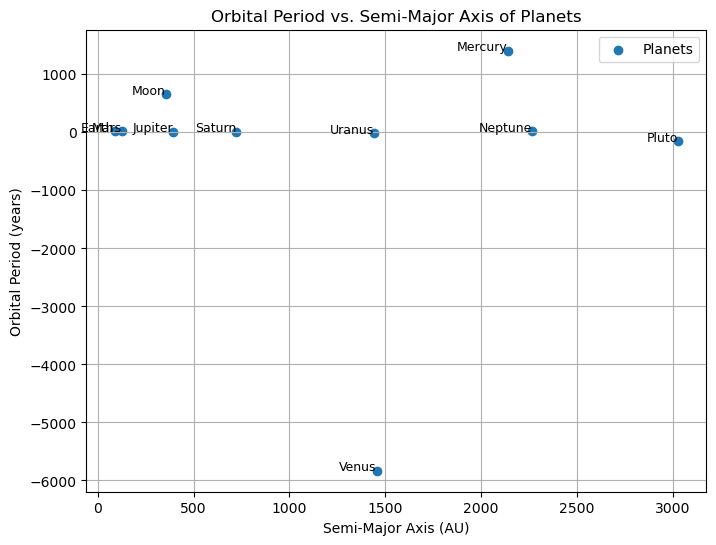

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(semi_major_axis, orbital_period, label="Planets")

for planet in semi_major_axis.index:
    x = semi_major_axis[planet]
    y = orbital_period[planet]
    plt.text(x, y, planet, fontsize=9, ha='right')

plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (years)")

plt.title("Orbital Period vs. Semi-Major Axis of Planets")
plt.legend()

plt.grid(True)
plt.show()

In [27]:
def keplers_third_law(a, m):
    return m * a ** 1.5

In [28]:
def kepler_model(a, k):
    return k * a**1.5

a_data = np.array(semi_major_axis, dtype=float)
P_data = np.array(orbital_period, dtype=float)

popt, pcov = curve_fit(kepler_model, a_data, P_data)

k_best = popt[0]

In [29]:
print(f"Best-fit parameter k = {k_best:.2f}")
print(f"Fitted model: P = {k_best:.2f} * a^(3/2)")

Best-fit parameter k = -0.00
Fitted model: P = -0.00 * a^(3/2)


In [30]:
sigma = np.ones_like(P_data)

residuals = P_data - kepler_model(a_data, k_best)

chi2 = np.sum((residuals / sigma)**2)

ndof = len(P_data) - 1

chi2_red = chi2 / ndof
print(f"Reduced chi-squared = {chi2_red:.2f}")

Reduced chi-squared = 3967335.47


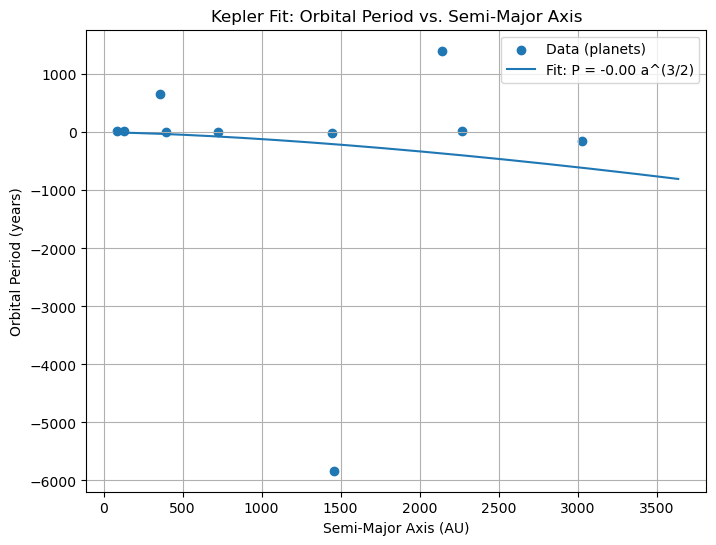

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(a_data, P_data, label="Data (planets)")

a_fit = np.linspace(a_data.min()*0.8, a_data.max()*1.2, 200)
P_fit = kepler_model(a_fit, k_best)
plt.plot(a_fit, P_fit, label=f"Fit: P = {k_best:.2f} a^(3/2)")

plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (years)")
plt.title("Kepler Fit: Orbital Period vs. Semi-Major Axis")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
df.to_csv("kepler.csv", index=False)